In [1]:
# packages and working directory  
import scipy 
import sklearn

import econml 
import arch
import os 
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib as plt
import statsmodels.api as sm 
from statsmodels.discrete.discrete_model import Probit
from statsmodels.iolib.summary2 import summary_col
import statsmodels.formula.api as smf 
from scipy.optimize import minimize
from scipy.special import logsumexp
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt 
from scipy import stats
from scipy.stats import ttest_ind
import biogeme.database as db
import biogeme.biogeme as bio 
import biogeme.models as models 
import biogeme.version as ver 
from biogeme.expressions import Beta, log,Variable
from ipywidgets import interactive, FloatSlider
from scipy.optimize import fsolve
import ipywidgets as widgets

# Consolidate changing directory and CPI dictionary since these don't change throughout the script
new_directory = r'C:\Users\hisham\Spain\2021 datasets'
os.chdir(new_directory)


In [2]:
# Read the data files
df_h0 = pd.read_csv('H0.txt', sep='\t')
df_h1 = pd.read_csv('H1.txt', sep='\t')
df_h2 = pd.read_csv('H2.txt', sep='\t')
df_h3 = pd.read_csv('H3.txt', sep='\t')
filtered_df = pd.read_csv('filtered1.csv')
# Assign scenario identifiers
df_h0['scenario'] = 'h0'
df_h1['scenario'] = 'h1'
df_h2['scenario'] = 'h2'
df_h3['scenario'] = 'h3'

# Concatenate into long format DataFrame
long_df = pd.concat([df_h0, df_h1, df_h2, df_h3], ignore_index=True)

# Assuming filtered_df is already defined and contains 'idperson', 'original_scenario', 'lhw_h0', 'lhw_h1', 'lhw_h2', 'lhw_h3'
long_df = long_df.merge(filtered_df[['idperson', 'original_scenario', 'lhw_h0', 'lhw_h1', 'lhw_h2', 'lhw_h3']], on='idperson', how='left')

# Create 'choice_made' binary variable: 1 if the scenario matches the original choice, 0 otherwise
long_df['choice_made'] = (long_df['scenario'] == long_df['original_scenario']).astype(int)

# Calculate leisure time
long_df['leisure'] = 80 - long_df['lhw']

# Sort by 'idperson'
long_df = long_df.sort_values(by='idperson')



In [3]:
#copy
df = long_df.copy()

In [4]:
#mapping and filtration
def map_lhw(row):
    # Ensure the scenario prefix 'h' is included when constructing the column name
    scenario_prefix = 'h' if not row["scenario"].startswith('h') else ''
    scenario_column_name = f'lhw_{scenario_prefix}{row["scenario"]}'
    return row[scenario_column_name]

# Apply the corrected function
df['lhw_scenario'] = df.apply(map_lhw, axis=1)

# Print a sample to verify the column has been created correctly
print(df[['idperson', 'scenario', 'lhw_scenario']].head())
# Identify individuals with any negative 'ils_udb_yds' values
negative_c_ids = df[df['ils_udb_yds'] <=  0]['idperson'].unique()
# Identify individuals with any negative 'ils_udb_yds' values
negative_l_ids = df[df['lhw_scenario'] >= 80 ]['idperson'].unique()
print(f"Number of individuals with negative leisure: {len(negative_l_ids)}")
print(f"Number of individuals with negative consumption: {len(negative_c_ids)}")

# Filter df to exclude all rows belonging to individuals identified in step 1 or step 2
df_filtered = df[~df['idperson'].isin(negative_c_ids) & ~df['idperson'].isin(negative_l_ids)]
# Verify the removal
print(f"Original dataframe size: {df.shape}")
print(f"Filtered dataframe size: {df_filtered.shape}")


       idperson scenario  lhw_scenario
0      87060001       h0           0.0
11030  87060001       h2          44.0
16545  87060001       h3          55.0
5515   87060001       h1          15.0
1      87070001       h0           0.0
Number of individuals with negative leisure: 3
Number of individuals with negative consumption: 135
Original dataframe size: (22060, 385)
Filtered dataframe size: (21508, 385)


In [5]:
#creating logs
df_filtered['consum'] = np.log((df_filtered['ils_udb_yds'])+1)
df_filtered['logleis'] = np.log((80 - df_filtered['lhw_scenario'])+1)
df_filtered['logy'] = np.log((df_filtered['ils_udb_yds'])+1)
df_filtered['logl'] = np.log((80 - df_filtered['lhw_scenario'])+1)
df_filtered['logy2'] = df_filtered['logy'] ** 2
df_filtered['logl2'] = df_filtered['logl'] ** 2
df_filtered['logyl'] = df_filtered['logy'] * df_filtered['logl']
df_filtered = df_filtered.sort_values(by='idperson')


C:\Users\hisham\AppData\Local\Temp\ipykernel_30440\804728042.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['consum'] = np.log((df_filtered['ils_udb_yds'])+1)
C:\Users\hisham\AppData\Local\Temp\ipykernel_30440\804728042.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['logleis'] = np.log((80 - df_filtered['lhw_scenario'])+1)
C:\Users\hisham\AppData\Local\Temp\ipykernel_30440\804728042.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataF

In [6]:
long_df = df_filtered.copy()

In [7]:
# Transform to wide format for Biogeme
wide_df = long_df.pivot(index='idperson', columns='scenario', values=['logy', 'logl', 'logy2', 'logl2', 'logyl'])
wide_df.columns = [f'{var}_{scen}' for var, scen in wide_df.columns]
wide_df.reset_index(inplace=True)

# Verify the transformed wide format DataFrame
print(wide_df.head())


   idperson   logy_h0   logy_h1   logy_h2   logy_h3   logl_h0   logl_h1  \
0  87060001  6.735067  6.936673  7.841831  8.059109  4.394449  4.189655   
1  87070001  7.320891  7.320891  7.320891  7.320891  4.394449  4.290459   
2  87090001  6.709999  7.167848  8.105549  8.441803  4.394449  4.276666   
3  87380001  6.265301  6.265301  7.350568  7.749331  4.394449  4.304065   
4  87700002  6.371817  6.721245  7.110459  7.466159  4.394449  4.343805   

    logl_h2   logl_h3   logy2_h0  ...   logy2_h2   logy2_h3   logl2_h0  \
0  3.610918  3.258097  45.361130  ...  61.494312  64.949232  19.311183   
1  3.951244  3.258097  53.595443  ...  53.595443  53.595443  19.311183   
2  3.784190  3.295837  45.024090  ...  65.699925  71.264046  19.311183   
3  3.828641  3.295837  39.253999  ...  54.030843  60.052132  19.311183   
4  3.931826  3.178054  40.600051  ...  50.558632  55.743529  19.311183   

    logl2_h1   logl2_h2   logl2_h3   logyl_h0   logyl_h1   logyl_h2   logyl_h3  
0  17.553207  13.038728

In [8]:
# Merge the 'original_choice' to mark the chosen scenario
wide_df = wide_df.merge(filtered_df[['idperson', 'original_scenario']], on='idperson', how='left')

wide_df.head()

,idperson,logy_h0,logy_h1,logy_h2,logy_h3,logl_h0,logl_h1,logl_h2,logl_h3,logy2_h0,...,logy2_h3,logl2_h0,logl2_h1,logl2_h2,logl2_h3,logyl_h0,logyl_h1,logyl_h2,logyl_h3,original_scenario
0,87060001,6.735067,6.936673,7.841831,8.059109,4.394449,4.189655,3.610918,3.258097,45.361130,...,64.949232,19.311183,17.553207,13.038728,10.615193,29.596910,29.062265,28.316208,26.257354,h2
1,87070001,7.320891,7.320891,7.320891,7.320891,4.394449,4.290459,3.951244,3.258097,53.595443,...,53.595443,19.311183,18.408042,15.612327,10.615193,32.171283,31.409985,28.926624,23.852169,h0
2,87090001,6.709999,7.167848,8.105549,8.441803,4.394449,4.276666,3.784190,3.295837,45.024090,...,71.264046,19.311183,18.289873,14.320091,10.862541,29.486750,30.654492,30.672935,27.822807,h2
3,87380001,6.265301,6.265301,7.350568,7.749331,4.394449,4.304065,3.828641,3.295837,39.253999,...,60.052132,19.311183,18.524976,14.658495,10.862541,27.532548,26.966264,28.142687,25.540531,h2
4,87700002,6.371817,6.721245,7.110459,7.466159,4.394449,4.343805,3.931826,3.178054,40.600051,...,55.743529,19.311183,18.868646,15.459253,10.100026,28.000626,29.195780,27.957086,23.727855,h2


In [9]:
scenario_mapping = {'h0': 0, 'h1': 1, 'h2': 2, 'h3': 3}

wide_df['original_scenario'] = wide_df['original_scenario'].map(scenario_mapping)

wide_df.head()

,idperson,logy_h0,logy_h1,logy_h2,logy_h3,logl_h0,logl_h1,logl_h2,logl_h3,logy2_h0,...,logy2_h3,logl2_h0,logl2_h1,logl2_h2,logl2_h3,logyl_h0,logyl_h1,logyl_h2,logyl_h3,original_scenario
0,87060001,6.735067,6.936673,7.841831,8.059109,4.394449,4.189655,3.610918,3.258097,45.361130,...,64.949232,19.311183,17.553207,13.038728,10.615193,29.596910,29.062265,28.316208,26.257354,2.0
1,87070001,7.320891,7.320891,7.320891,7.320891,4.394449,4.290459,3.951244,3.258097,53.595443,...,53.595443,19.311183,18.408042,15.612327,10.615193,32.171283,31.409985,28.926624,23.852169,0.0
2,87090001,6.709999,7.167848,8.105549,8.441803,4.394449,4.276666,3.784190,3.295837,45.024090,...,71.264046,19.311183,18.289873,14.320091,10.862541,29.486750,30.654492,30.672935,27.822807,2.0
3,87380001,6.265301,6.265301,7.350568,7.749331,4.394449,4.304065,3.828641,3.295837,39.253999,...,60.052132,19.311183,18.524976,14.658495,10.862541,27.532548,26.966264,28.142687,25.540531,2.0
4,87700002,6.371817,6.721245,7.110459,7.466159,4.394449,4.343805,3.931826,3.178054,40.600051,...,55.743529,19.311183,18.868646,15.459253,10.100026,28.000626,29.195780,27.957086,23.727855,2.0


In [10]:
# Create a Biogeme database
database = db.Database('labour_supply', wide_df)

# Verify the database structure
print(database.data.dtypes)


The database contains NaN value(s). Detect where they are using the function isnan()


BiogemeError: The database contains NaN value(s). Detect where they are using the function isnan()

In [ ]:
# Define variables for each scenario
logy_h0 = Variable('logy_h0')
logl_h0 = Variable('logl_h0')
logy2_h0 = Variable('logy2_h0')
logl2_h0 = Variable('logl2_h0')
logyl_h0 = Variable('logyl_h0')

logy_h1 = Variable('logy_h1')
logl_h1 = Variable('logl_h1')
logy2_h1 = Variable('logy2_h1')
logl2_h1 = Variable('logl2_h1')
logyl_h1 = Variable('logyl_h1')

logy_h2 = Variable('logy_h2')
logl_h2 = Variable('logl_h2')
logy2_h2 = Variable('logy2_h2')
logl2_h2 = Variable('logl2_h2')
logyl_h2 = Variable('logyl_h2')

logy_h3 = Variable('logy_h3')
logl_h3 = Variable('logl_h3')
logy2_h3 = Variable('logy2_h3')
logl2_h3 = Variable('logl2_h3')
logyl_h3 = Variable('logyl_h3')

choice = Variable('original_scenario')



In [ ]:
# Define parameters to be estimated
alpha = Beta('alpha', 0, None, None, 0)
beta = Beta('beta', 0, None, None, 0)
gamma_yy = Beta('gamma_yy', 0, None, None, 0)
gamma_ll = Beta('gamma_ll', 0, None, None, 0)
gamma_yl = Beta('gamma_yl', 0, None, None, 0)

# Define the utility functions
V = {
    0: alpha * logy_h0 + beta * logl_h0 + gamma_yy * logy2_h0 + gamma_ll * logl2_h0 + gamma_yl * logyl_h0,
    1: alpha * logy_h1 + beta * logl_h1 + gamma_yy * logy2_h1 + gamma_ll * logl2_h1 + gamma_yl * logyl_h1,
    2: alpha * logy_h2 + beta * logl_h2 + gamma_yy * logy2_h2 + gamma_ll * logl2_h2 + gamma_yl * logyl_h2,
    3: alpha * logy_h3 + beta * logl_h3 + gamma_yy * logy2_h3 + gamma_ll * logl2_h3 + gamma_yl * logyl_h3
}

# Define the availability of each choice (all choices are available)
av = {0: 1, 1: 1, 2: 1, 3: 1}

# Associate the utility functions with the choice situations
logprob = models.loglogit(V, av, choice)


In [ ]:
# Create the Biogeme object
biogeme_model = bio.BIOGEME(database, logprob)

# Set the choice variable
biogeme_model.choice = choice

# Estimate the parameters
results = biogeme_model.estimate()

# Print the estimated parameters
print(results.getEstimatedParameters())


You have not defined a name for the model. The output files are named from the model name. The default is [biogemeModelDefaultName]


              Value  Rob. Std err  Rob. t-test  Rob. p-value
alpha     -6.921473      0.536985   -12.889519           0.0
beta      25.093134      1.316729    19.057170           0.0
gamma_ll  -4.212777      0.136606   -30.838933           0.0
gamma_yl   1.206946      0.074227    16.260103           0.0
gamma_yy   0.354953      0.031637    11.219512           0.0


In [24]:
# biogeme translog (biased)
res = [ -6.921473,  25.093134,  0.354953, -4.212777, 1.206946]   
# Automated calculation of points where marginal utilities become negative
mu_y_neg = np.exp(- (res[0] + res[4] * df_filtered['logl'].mean()) / ( 2 * res[2]))
mu_l_neg = np.exp(- (res[1] + res[4] * df_filtered['logy'].mean()) / (2* res[3]))

print(f"Income level at which MU of income becomes negative: {mu_y_neg}")
print(f"Leisure level at which MU of leisure becomes negative: {mu_l_neg}")

Income level at which MU of income becomes negative: 22.59024635039899
Leisure level at which MU of leisure becomes negative: 53.681619005829745


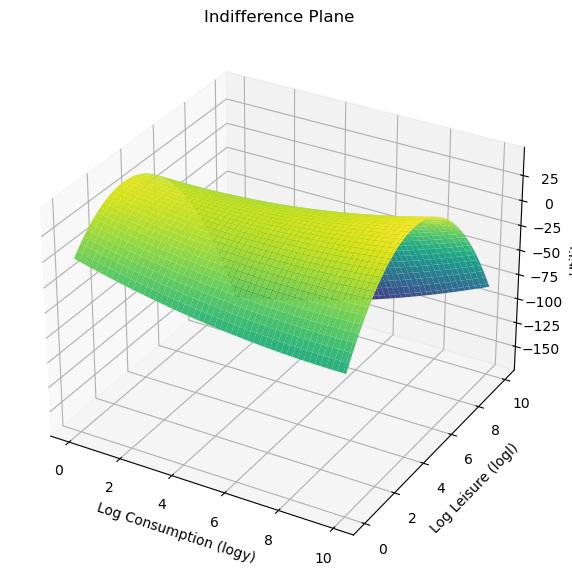

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the utility function with the estimated parameters
def utility(logy, logl, alpha, beta, gamma_yy, gamma_ll, gamma_yl):
    logy2 = logy ** 2
    logl2 = logl ** 2
    logyl = logy * logl
    return alpha * logy + beta * logl + gamma_yy * logy2 + gamma_ll * logl2 + gamma_yl * logyl

# Estimated parameters
alpha = -6.921473
beta = 25.093134
gamma_yy = 0.354953
gamma_ll = -4.212777
gamma_yl = 1.206946
# Generate a range of values for log consumption (logy) and log leisure (logl)
logy_values = np.linspace(0, 10, 100)
logl_values = np.linspace(0, 10, 100)

# Create a grid of values
logy_grid, logl_grid = np.meshgrid(logy_values, logl_values)
# Calculate utility for each combination of logy and logl
utility_values = utility(logy_grid, logl_grid, alpha, beta, gamma_yy, gamma_ll, gamma_yl)
# Create a 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(logy_grid, logl_grid, utility_values, cmap='viridis')

# Set labels
ax.set_xlabel('Log Consumption (logy)')
ax.set_ylabel('Log Leisure (logl)')
ax.set_zlabel('Utility')

# Set title
ax.set_title('Indifference Plane')

# Show the plot
plt.show()


In [26]:
# Generate a range of values for log consumption (logy) and log leisure (logl)
logy_values = np.linspace(0, 10, 100)
logl_values = np.linspace(0, 10, 100)

# Create a grid of values
logy_grid, logl_grid = np.meshgrid(logy_values, logl_values)


In [27]:
# Calculate utility for each combination of logy and logl
utility_values = utility(logy_grid, logl_grid, alpha, beta, gamma_yy, gamma_ll, gamma_yl)


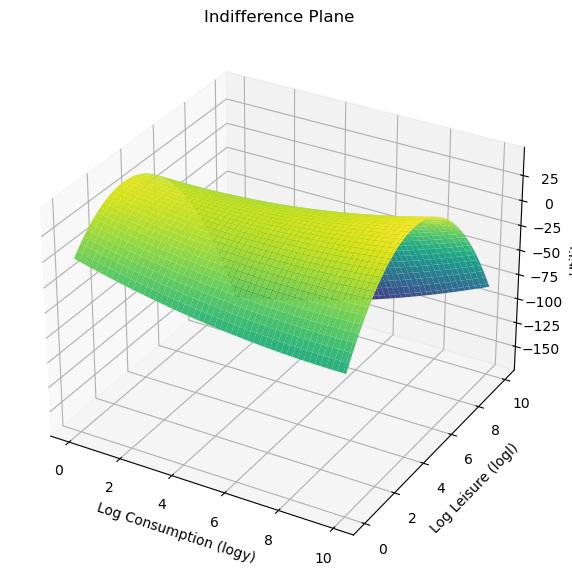

In [28]:
# Create a 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(logy_grid, logl_grid, utility_values, cmap='viridis')

# Set labels
ax.set_xlabel('Log Consumption (logy)')
ax.set_ylabel('Log Leisure (logl)')
ax.set_zlabel('Utility')

# Set title
ax.set_title('Indifference Plane')

# Show the plot
plt.show()


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
from ipywidgets import interactive


In [30]:
# Define the function to create the 3D plot
def plot_indifference_plane(alpha, beta, gamma_yy, gamma_ll, gamma_yl):
    logy_values = np.linspace(0, 10, 100)
    logl_values = np.linspace(0, 10, 100)
    logy_grid, logl_grid = np.meshgrid(logy_values, logl_values)
    utility_values = utility(logy_grid, logl_grid, alpha, beta, gamma_yy, gamma_ll, gamma_yl)
    
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(logy_grid, logl_grid, utility_values, cmap='viridis')
    
    ax.set_xlabel('Log Consumption (logy)')
    ax.set_ylabel('Log Leisure (logl)')
    ax.set_zlabel('Utility')
    ax.set_title('Indifference Plane')
    
    plt.show()

# Interactive plot using ipywidgets
interactive_plot = interactive(plot_indifference_plane,
                               alpha=widgets.FloatSlider(value=-6.921473, min=-100, max=100, step=0.01),
                               beta=widgets.FloatSlider(value=25.093134, min=-100, max=100, step=0.01),
                               gamma_yy=widgets.FloatSlider(value=0.354953, min=-10, max=10, step=0.00001),
                               gamma_ll=widgets.FloatSlider(value=-4.212777, min=-10, max=10, step=0.00001),
                               gamma_yl=widgets.FloatSlider(value=1.206946, min=-20, max=20, step=0.0001))

# Display the interactive plot
interactive_plot


interactive(children=(FloatSlider(value=-6.921473, description='alpha', min=-100.0, step=0.01), FloatSlider(va…

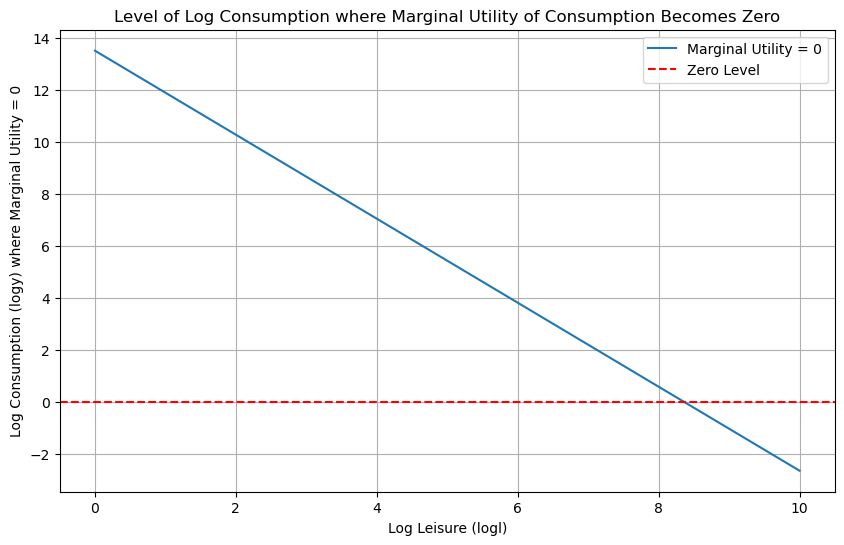

In [17]:
#plots
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# Define the marginal utility function
def marginal_utility_logy(logy, alpha, gamma_yy, gamma_yl, logl):
    return alpha + 2 * gamma_yy * logy + gamma_yl * logl

# Estimated parameters
alpha = 7.54
beta =  62.18411
gamma_yy = -.278983
gamma_ll = -9.167373
gamma_yl = -.902409

# Define a range of log leisure (logl) values to analyze
logl_values = np.linspace(0, 10, 100)
logy_negative_mu = []

# Solve for logy where the marginal utility becomes zero for each logl
for logl in logl_values:
    # Initial guess for logy
    initial_guess = 5
    logy_solution = fsolve(marginal_utility_logy, initial_guess, args=(alpha, gamma_yy, gamma_yl, logl))
    logy_negative_mu.append(logy_solution[0])

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(logl_values, logy_negative_mu, label='Marginal Utility = 0')
plt.axhline(y=0, color='r', linestyle='--', label='Zero Level')
plt.xlabel('Log Leisure (logl)')
plt.ylabel('Log Consumption (logy) where Marginal Utility = 0')
plt.title('Level of Log Consumption where Marginal Utility of Consumption Becomes Zero')
plt.legend()
plt.grid(True)
plt.show()


In [18]:
## means 
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Assuming df_combined is your DataFrame that contains 'logl' values
mean_logl = df_filtered['logl'].mean()
mean_logy = df_filtered['logy'].mean()
print(f'Mean log leisure (logl): {mean_logl}')
print(f'Mean log of consumption (logy): {mean_logy}')

Mean log leisure (logl): 3.901026308851387
Mean log of consumption (logy): 7.014765257660128


In [19]:
# Define the utility function with the estimated parameters
def utility(logy, logl, alpha, beta, gamma_yy, gamma_ll, gamma_yl):
    logy2 = logy ** 2
    logl2 = logl ** 2
    logyl = logy * logl
    return alpha * logy + beta * logl + gamma_yy * logy2 + gamma_ll * logl2 + gamma_yl * logyl

# Define the marginal utility function
def marginal_utility_y(y, alpha, gamma_yy, gamma_yl, logl):
    logy = np.log(y)
    return (alpha + 2 * gamma_yy * logy + gamma_yl * logl) / y


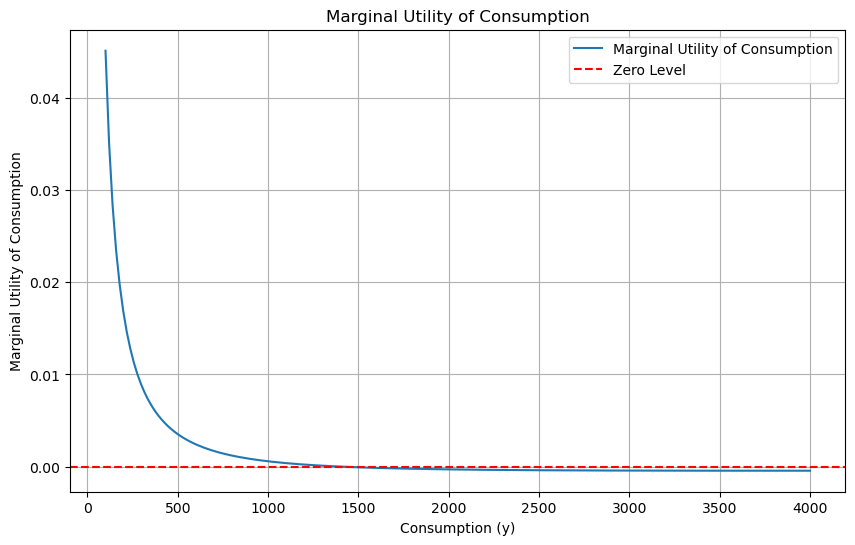

In [20]:
# Estimated parameters and plotting 
alpha = 18.67929
beta =  76.10686
gamma_yy =  -.85504 
gamma_ll = -10.3286
gamma_yl = -1.613091

# Define a range of consumption (y) values
y_values = np.linspace(100, 4000, 200)  # Avoid zero to prevent division by zero

# Calculate the marginal utility for each y value using the mean log leisure (logl)
marginal_utility_values = marginal_utility_y(y_values, alpha, gamma_yy, gamma_yl, mean_logl)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(y_values, marginal_utility_values, label='Marginal Utility of Consumption')
plt.axhline(y=0, color='r', linestyle='--', label='Zero Level')
plt.xlabel('Consumption (y)')
plt.ylabel('Marginal Utility of Consumption')
plt.title('Marginal Utility of Consumption')
plt.legend()
plt.grid(True)
plt.show()


In [21]:
# Define the marginal utility functions
def marginal_utility_consumption(y, alpha, gamma_yy, gamma_yl, logl):
    logy = np.log(y)
    return (alpha + 2 * gamma_yy * logy + gamma_yl * logl) / y

def marginal_utility_leisure(l, beta, gamma_ll, gamma_yl, logy):
    return (beta + 2 * gamma_ll * np.log(l) + gamma_yl * logy) / l

# Plotting function for marginal utility of consumption
def plot_marginal_utility_consumption(alpha, gamma_yy, gamma_yl):
    y_values = np.linspace(100, 5000, 200)  # Avoid zero to prevent division by zero
    marginal_utility_values = marginal_utility_consumption(y_values, alpha, gamma_yy, gamma_yl, mean_logl)
    
    plt.figure(figsize=(10, 6))
    plt.plot(y_values, marginal_utility_values, label='Marginal Utility of Consumption')
    plt.axhline(y=0, color='r', linestyle='--', label='Zero Level')
    plt.xlabel('Income (y)')
    plt.ylabel('Marginal Utility of Consumption')
    plt.title('Marginal Utility of Consumption vs. Consumption')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plotting function for marginal utility of leisure
def plot_marginal_utility_leisure(beta, gamma_ll, gamma_yl):
    l_values = np.linspace(1, 79.99, 100)
    marginal_utility_values = marginal_utility_leisure(l_values, beta, gamma_ll, gamma_yl, mean_logy)
    
    plt.figure(figsize=(10, 6))
    plt.plot(l_values, marginal_utility_values, label='Marginal Utility of Leisure')
    plt.axhline(y=0, color='r', linestyle='--', label='Zero Level')
    plt.xlabel('Leisure (l)')
    plt.ylabel('Marginal Utility of Leisure')
    plt.title('Marginal Utility of Leisure vs. Leisure')
    plt.legend()
    plt.grid(True)
    plt.show()


In [22]:
# Assuming df_combined is your DataFrame that contains 'logl' and 'logy' values
# Assuming df_combined is your DataFrame that contains 'logl' values
mean_logl = np.log(80-38)
mean_logy = np.log(1650)
print(f'Mean log leisure (logl): {mean_logl}')
print(f'Mean log of consumption (logy): {mean_logy}')


Mean log leisure (logl): 3.7376696182833684
Mean log of consumption (logy): 7.408530566894626


In [23]:
# Interactive widgets for marginal utility of consumption
interactive_consumption = interactive(plot_marginal_utility_consumption,
                                      alpha=FloatSlider(value=8.953565, min=-100, max=100, step=0.01),
                                      gamma_yy=FloatSlider(value=-0.8974447, min=-20, max=10, step=0.01),
                                      gamma_yl=FloatSlider(value=-0.3632114, min=-10, max=10, step=0.01))

# Display the interactive plot for marginal utility of consumption
display(interactive_consumption)

# Interactive widgets for marginal utility of leisure
interactive_leisure = interactive(plot_marginal_utility_leisure,
                                  beta=FloatSlider(value=38.36, min=-10, max=100, step=0.01),
                                  gamma_ll=FloatSlider(value=-9.543114, min=-20, max=10, step=0.01),
                                  gamma_yl=FloatSlider(value=-0.3632114, min=-10, max=10, step=0.01))

# Display the interactive plot for marginal utility of leisure
display(interactive_leisure)


interactive(children=(FloatSlider(value=8.953565, description='alpha', min=-100.0, step=0.01), FloatSlider(val…

interactive(children=(FloatSlider(value=38.36, description='beta', min=-10.0, step=0.01), FloatSlider(value=-9…